In [1]:
import cv2
import numpy as np
from visualization import show_samples, class_counting
import matplotlib.pyplot as plt
from datasets import Coralscapes
from folder_manipulate import refactor_file_name
import os
import shutil

CORAL_ALIVE = [6, 17, 21, 22, 25, 27, 28, 31, 34, 36]
CORAL_DEAD = [3, 18, 20, 23, 32, 37]
CORAL_BLEACHED = [4, 16, 19, 33]
ALGAE_SUBSTRATE = [10]
UNKNOWN_SUBSTRATE = [12]

GRAY_COLOR_MAPPING = {
    **{k: 10 for k in CORAL_ALIVE},
    **{k: 20 for k in CORAL_DEAD},
    **{k: 30 for k in CORAL_BLEACHED},
    **{k: 40 for k in ALGAE_SUBSTRATE},
    **{k: 50 for k in UNKNOWN_SUBSTRATE}
}

REMOVE_CLASSES = [
    1, 2, 5, 7, 8, 9, 11, 13, 14, 15,
    24, 26, 29, 30, 35, 38, 39
]

CORAL_ALIVE_ID = 1
CORAL_DEAD_ID = 2
CORAL_BLEACHED_ID = 3
ALGAE_SUBSTRATE_ID = 4
UNKNOWN_SUBSTRATE_ID = 5



In [2]:
coralscapes_temp_dir = "D:\\AI_ENGINEER\\Pycharm\\UOD_Temps\\temps\\coralscapes" # Update based on the location of your coralscapes
train_dataset = Coralscapes(root = coralscapes_temp_dir, split = 'train')
val_dataset = Coralscapes(root = coralscapes_temp_dir, split = 'val')
test_dataset = Coralscapes(root = coralscapes_temp_dir, split = 'test')

image, label = test_dataset[0]

# Đối với bài toán segmentation thì ảnh label sẽ là các class indices
print(f"Image shape: {image.shape}")

print(f"Label shape: {label.shape}")
print(f"Data type: {label.dtype}")
print(f"Min value: {label.min()}")
print(f"Max value: {label.max()}")
print(f"Unique values: {np.unique(label)}")

Image shape: (1024, 2048, 3)
Label shape: (1024, 2048)
Data type: uint8
Min value: 0
Max value: 23
Unique values: [ 0  6  9 10 11 12 14 15 16 23]


In [3]:
print(f"Total num_classes are : {len(train_dataset.classes)}")

for idx, coral_class in enumerate(train_dataset.classes):

    print(f"Class {idx} : {coral_class.name}")



Total num_classes are : 40
Class 0 : unlabeled
Class 1 : seagrass
Class 2 : trash
Class 3 : other coral dead
Class 4 : other coral bleached
Class 5 : sand
Class 6 : other coral alive
Class 7 : human
Class 8 : transect tools
Class 9 : fish
Class 10 : algae covered substrate
Class 11 : other animal
Class 12 : unknown hard substrate
Class 13 : background
Class 14 : dark
Class 15 : transect line
Class 16 : massive/meandering bleached
Class 17 : massive/meandering alive
Class 18 : rubble
Class 19 : branching bleached
Class 20 : branching dead
Class 21 : millepora
Class 22 : branching alive
Class 23 : massive/meandering dead
Class 24 : clam
Class 25 : acropora alive
Class 26 : sea cucumber
Class 27 : turbinaria
Class 28 : table acropora alive
Class 29 : sponge
Class 30 : anemone
Class 31 : pocillopora alive
Class 32 : table acropora dead
Class 33 : meandering bleached
Class 34 : stylophora alive
Class 35 : sea urchin
Class 36 : meandering alive
Class 37 : meandering dead
Class 38 : crown of 

In [4]:
CLASS_VALUES_ = list(range(1, 40))
class_counting(test_dataset,CLASS_VALUES_)


defaultdict(int,
            {1: 16,
             2: 58,
             3: 88,
             4: 124,
             5: 1129,
             6: 1800,
             7: 26,
             8: 81,
             9: 5331,
             10: 4020,
             11: 78,
             12: 8650,
             13: 1086,
             14: 6314,
             15: 400,
             16: 210,
             17: 2447,
             18: 1353,
             19: 86,
             20: 906,
             21: 259,
             22: 562,
             23: 1417,
             24: 28,
             25: 249,
             26: 17,
             27: 16,
             28: 20,
             29: 122,
             30: 15,
             31: 359,
             32: 50,
             33: 33,
             34: 103,
             35: 192,
             36: 568,
             37: 344,
             38: 16,
             39: 7})

VISUALIZATION


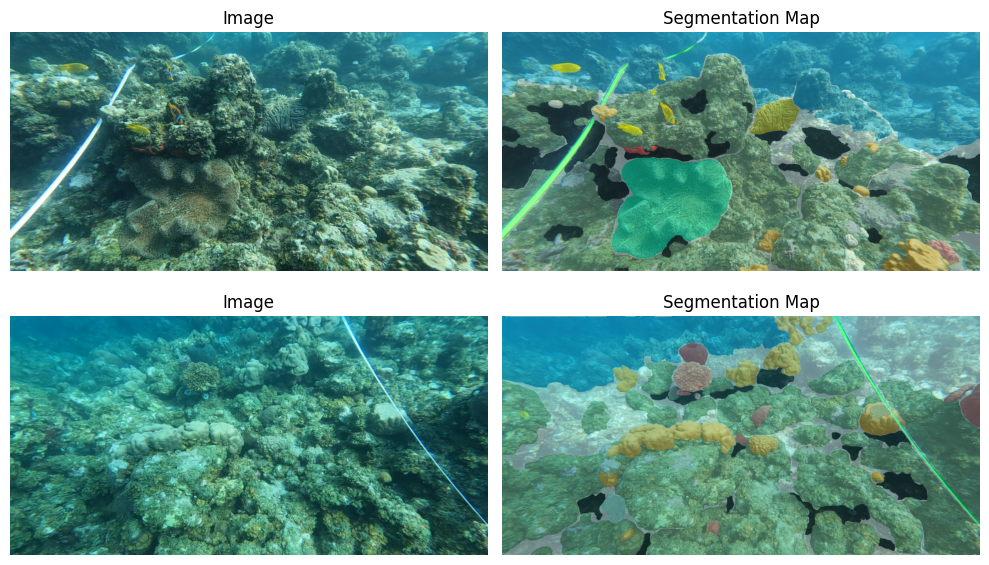

In [4]:
show_samples(train_dataset, n=2)

REFACTOR_DATASET_FOLDER


In [4]:
# Label
refactor_label_folder = "../../dataset/segmentation/coral/new_mask_gt"
original_label_folder = "../../dataset/segmentation/temps/gtFine"
if os.path.exists(refactor_label_folder):
    shutil.rmtree(refactor_label_folder)
shutil.copytree(original_label_folder, refactor_label_folder)
# Image
refactor_image_folder = "../../dataset/segmentation/coral/new_img"
original_image_folder = "../../dataset/segmentation/temps/leftImg8bit"
if os.path.exists(refactor_image_folder):
    shutil.rmtree(refactor_image_folder)
shutil.copytree(original_image_folder, refactor_image_folder)
# Refactor
dataset_folder = "../../dataset/segmentation/coral"
refactor_file_name(dataset_folder)


Refactor success dataset folder


In [5]:
# Lookup Table
lut = np.zeros(256,dtype=np.uint8)
for key,value in GRAY_COLOR_MAPPING.items():
    lut[key] = value
print("Mapped classes:", sorted(GRAY_COLOR_MAPPING.keys()))
print("LUT unique values:", np.unique(lut))

Mapped classes: [3, 4, 6, 10, 12, 16, 17, 18, 19, 20, 21, 22, 23, 25, 27, 28, 31, 32, 33, 34, 36, 37]
LUT unique values: [ 0 10 20 30 40 50]


In [6]:
modes = ["train", "val", "test"]
for mode in modes :
    splited_mask_folder = os.path.join(refactor_label_folder,mode)
    for file_name in os.listdir(splited_mask_folder):
        mask_img_path = os.path.join(splited_mask_folder,file_name)
        mask_img = cv2.imread(mask_img_path,cv2.IMREAD_GRAYSCALE)
        new_mask_img = lut[mask_img].astype(np.uint8)
        cv2.imwrite(mask_img_path, new_mask_img)


In [5]:
coralscapes_root_dir = "../../dataset/segmentation/coral"
n_train_dataset = Coralscapes(root = coralscapes_root_dir, split = 'train', refactor_flag = "new_")
n_val_dataset = Coralscapes(root = coralscapes_root_dir, split = 'val',refactor_flag = "new_")
n_test_dataset = Coralscapes(root = coralscapes_root_dir, split = 'test',refactor_flag = "new_")

image, label = n_test_dataset[0]

# Đối với bài toán segmentation thì ảnh label sẽ là các class indices
print(f"Image shape: {image.shape}")

print(f"Label shape: {label.shape}")
print(f"Data type: {label.dtype}")
print(f"Min value: {label.min()}")
print(f"Max value: {label.max()}")
print(f"Unique values: {np.unique(label)}")

Image shape: (1024, 2048, 3)
Label shape: (1024, 2048)
Data type: uint8
Min value: 0
Max value: 50
Unique values: [ 0 10 20 30 40 50]


In [6]:
print(f"Total num_classes are : {len(n_train_dataset.classes)}")

# ['name', 'id', 'train_id', 'category', 'category_id','ignore_in_eval', 'color']

for idx, coral_class in enumerate(n_train_dataset.classes):
    print(f"Class {coral_class.name} id {coral_class.id} train_id {coral_class.train_id}")

Total num_classes are : 6
Class unlabeled id 0 train_id 0
Class coral-alive id 10 train_id 1
Class coral-dead id 20 train_id 2
Class coral-bleached id 30 train_id 3
Class algae covered substrate id 40 train_id 4
Class unknown hard substrate id 50 train_id 5


In [9]:
n_test_dataset.train_id_to_color

array([[255, 255, 255],
       [255,   0,   0],
       [ 29, 162, 216],
       [255, 255,   0],
       [194, 178, 128],
       [161, 153, 128]])

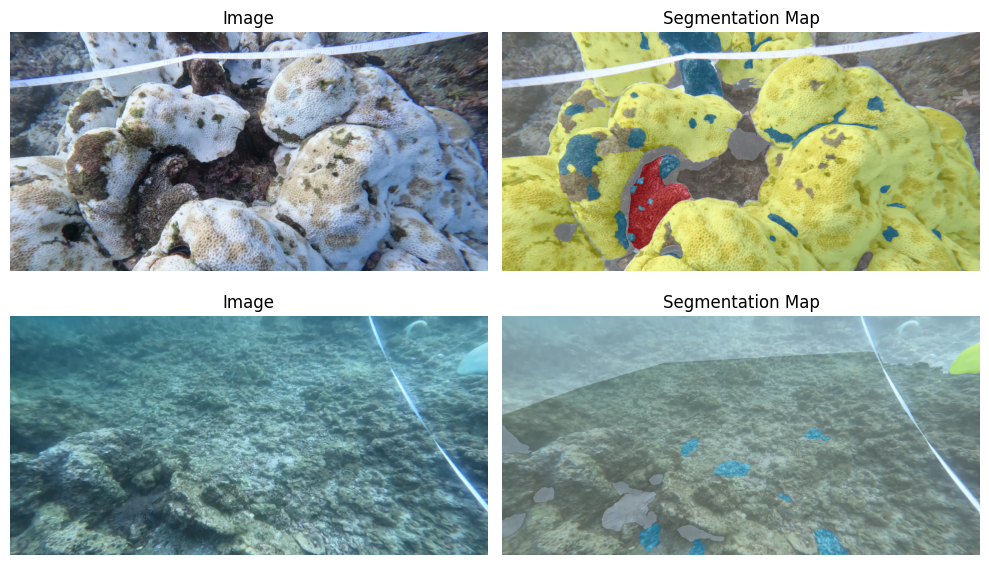

In [10]:
show_samples(n_test_dataset, n=2)

In [12]:
CLASS_VALUES = [10,20,30,40,50]

class_value_to_name_color = {
    10 : ("coral-alive",[255, 0, 0]),
    20 : ("coral-dead",[29, 162, 216]),
    30 : ("coral-bleached",[255, 255, 0]),
    40 : ("algae-covered-substrate",[194, 178, 128]),
    50 : ("unknown-hard-substrate", [161, 153, 128])
}

test_instance = class_counting(n_test_dataset,CLASS_VALUES)
train_instance = class_counting(n_train_dataset,CLASS_VALUES)
val_instance = class_counting(n_val_dataset,CLASS_VALUES)


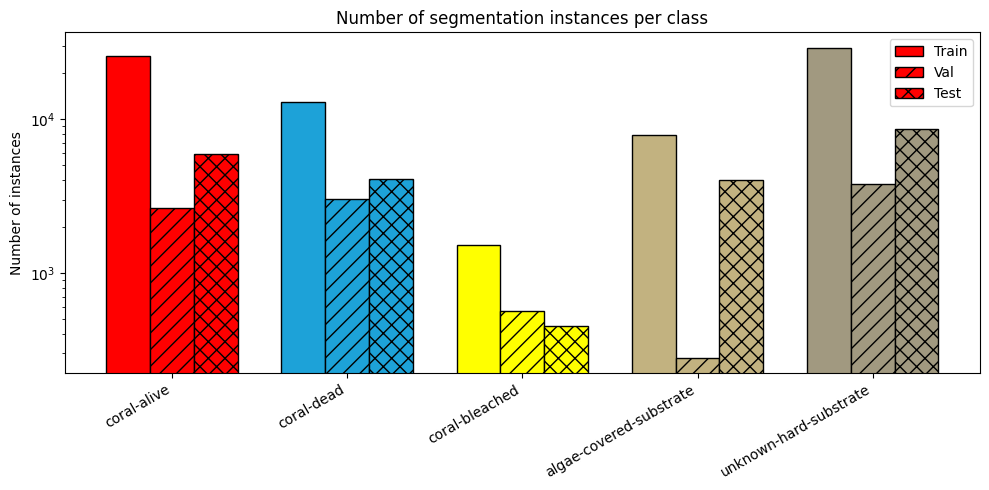

In [15]:
splits = ["Train", "Val", "Test"]
instances = [train_instance, val_instance, test_instance]
hatches = ["", "//", "xx"]

x = np.arange(len(CLASS_VALUES))
width = 0.25

plt.figure(figsize=(10, 5))

for i, (split, data, hatch) in enumerate(zip(splits, instances, hatches)):
    counts = [data[c] for c in CLASS_VALUES]
    colors = [np.array(class_value_to_name_color[c][1]) / 255 for c in CLASS_VALUES]

    plt.bar(
        x + i * width,
        counts,
        width=width,
        color=colors,
        edgecolor="black",
        hatch=hatch,
        label=split
    )

plt.xticks(
    x + width,
    [class_value_to_name_color[c][0] for c in CLASS_VALUES],
    rotation=30,
    ha="right"
)

plt.ylabel("Number of instances")
plt.yscale("log")
plt.title("Number of segmentation instances per class")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

rows = []
for c in CLASS_VALUES:
    rows.append({
        "Label": class_value_to_name_color[c][0],
        "Train": int(train_instance.get(c, 0)),
        "Val": int(val_instance.get(c, 0)),
        "Test": int(test_instance.get(c, 0)),
    })

df = pd.DataFrame(rows)
df["Total"] = df["Train"] + df["Val"] + df["Test"]


df = df.set_index("Label")[["Train", "Val", "Test", "Total"]]

display(df)


,Train,Val,Test,Total
Label,,,,
coral-alive,25597,2636,5922,34155
coral-dead,12980,3010,4054,20044
coral-bleached,1510,565,449,2524
algae-covered-substrate,7933,282,4020,12235
unknown-hard-substrate,29023,3790,8650,41463
